In [1]:
import numpy as np
import pandas as pd
from scipy import optimize
from scipy import stats
# Turn on a setting to use Pandas more safely.
# We will discuss this setting ®later.
pd.set_option('mode.chained_assignment', 'raise')

# Also - set up plotting
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('fivethirtyeight')

Matplotlib is building the font cache; this may take a moment.


### Our Data Scientist for today: Al-Kindi - an early code-breaker

<img src="AlKindi.png" align=right width=500>

- Born in Kufa, Iraq round year 800 CE, 
- Kufa was a centre for Islamic learning and culture. 
- Was asked to move to Baghdad by the Caliph Al- Ma’mun, where he was appointed as a calligrapher at the newly established academy known as the House of Wisdom (Bayt al-Hikma). 
- Al-Kindi, together with Al-Khawarizmi and the Banu Musa Brothers, worked on translating Greek texts to Arabic. 
     - Al-Kindi may not have participated much in the actual translations but knew Greek and was influenced by what he was reading.
- Known at the time for his work on Philosophy, but also Mathematics, Medicine, Optics, Astronomy and other sciences.
<br>

<img src="calligraphy.png">

- Described a method for cracking a substitution cipher
    - A substitution cipher substitutes one letter for another

```
“A Manuscript on Deciphering Cryptographic Messages“

“One way to solve an encrypted message, if we know its language, is to find a different 
plaintext of the same language long enough to fill one sheet or so, and then we count 
the occurrences of each letter. We call the most frequently occurring letter the ‘first’, 
the next most occurring letter the ‘second’, the following most occurring the ‘third’, 
and so on, until we account for all the different letters in the plaintext sample”.

“Then we look at the cipher text we want to solve and we also classify its symbols. 
We find the most occurring symbol and change it to the form of the ‘first’ letter 
of the plaintext sample, the next most common symbol is changed to the form of 
the ‘second’ letter, and so on, until we account for all symbols of the 
cryptogram we want to solve”
```

Can't be automated -- encoders can put in nonsense characters.  Guessing and intuition may be required.  Still, this is a powerful technique for cracking subsitution ciphers

### Outline:

Where are we?
- We've seen how to test differences between means
  - Mosquitoes and beer
- We've seen how to fit lines and test slopes
  - Cholesterol and heart disease
- We are working on testing differences in counts
  - Titanic</p><br>
 
- All use permutation tests
- Make sure you focus on what is the same and what is different in each case
  - The same:
    - Setting up an array for results
    - Setting up a loop to run simulations
    - Randomizing/permuting values to create the 'no difference' world
    - Plotting the outcome and calculating the probability that the real world is like the 'no difference' world
  - Different:
    - You may have to use ```optimize``` to fit data
    - You have to decide which values to scramble/permute
    - You have to decide what value is the critical value you need to save (and plot)</p><br>

#### Where do we go next
- Finish count data
- Binary logistic regression - Predicting yes/no present/absent outcomes
  - e.g. Was a disease present?
- Predicting an outcome using more than one predictor
  - Like linear regression, but using more than one x value to predict y
  - Multiple regression
  - e.g. predicting life expectancy using SES and exercise


### But first
#### Redundancy in Biosciences

In [2]:
rpool_women = 7
rpool_men = 6
redundancy_percent_women = rpool_women / (rpool_men+rpool_women)
print("The redundancy pool includes ",redundancy_percent_women,"% women")

The redundancy pool includes  0.5384615384615384 % women


In [3]:
dept_women = 23
dept_men = 45
# bioscience
dept_percent_women = dept_women/(dept_women+dept_men)
print("The department includes ",dept_percent_women,"% women")

The department includes  0.3382352941176471 % women


#### What is the probability that  7/13 people in the redundancy pool would be women
#### if the selection is unbiased from a department with 23 women and 45 men

In [70]:
# make a department to draw on
dept_pool = np.repeat(['w','m'],[dept_women,dept_men])
shuffled_pool = np.random.permutation(dept_pool)
shuffled_pool

array(['m', 'w', 'w', 'm', 'w', 'm', 'm', 'm', 'm', 'm', 'w', 'm', 'w',
       'm', 'm', 'w', 'w', 'm', 'm', 'm', 'w', 'w', 'm', 'm', 'm', 'w',
       'w', 'm', 'm', 'm', 'w', 'm', 'm', 'm', 'm', 'w', 'm', 'm', 'w',
       'w', 'm', 'm', 'w', 'm', 'm', 'w', 'w', 'm', 'm', 'w', 'm', 'm',
       'm', 'w', 'm', 'w', 'm', 'm', 'm', 'm', 'm', 'w', 'w', 'm', 'm',
       'm', 'm', 'm'], dtype='<U1')

probability of the actual outcome from a random selection:  0.08603
mean number of women in pool if random:  4.39407


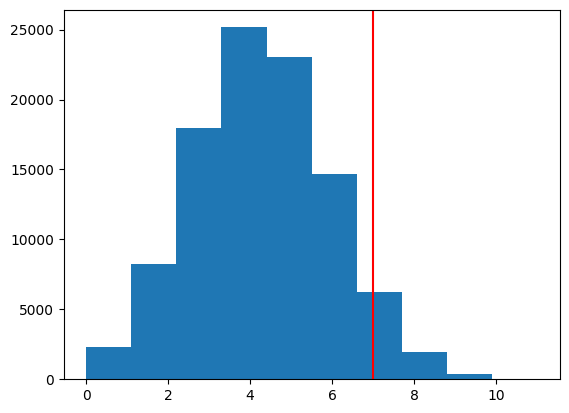

In [71]:
num_sim = 100000
pool_size = 13
num_women = np.zeros(num_sim)
for i in np.arange(0,num_sim):
    shuffled_dept = np.random.permutation(dept_pool)
    # print("pool: ",shuffled_dept[0:pool_size])
    num_women[i] = np.count_nonzero(shuffled_dept[0:pool_size] == 'w')
    # print("The number of women selected: ",num_women[i])

plt.hist(num_women)
plt.axvline(rpool_women,color="r")

probability_of_real_outcome = np.count_nonzero(num_women >= rpool_women)/num_sim
print("probability of the actual outcome from a random selection: ",probability_of_real_outcome)
print("mean number of women in pool if random: ",np.mean(num_women))

In [ ]:
#### What happens if you make the pool a bit bigger?

Try 14/26 women

### Comment on p-values

- Is the selection unbiased?
  - What is the appropriate p-value?</p><br>

- What is your personal p-value for getting on a plane?
  - Where p-value is probability of a crash


## Count data --
- We saw how to read in data
- We saw how to make a summary and plot
- Often where you start from is a summary table (raw data may not be available)
- How saw how to 'create' raw data from a summary table
- We saw what to shuffle

#### Where are we now?
- What is our critical value?
- Doing the permutation shuffle (a new (familiar) dance move)

### Read raw data
- Passenger list
  - Name, gender, age, relatives, fare
  - Who survived: survived = 1, died = 0

In [4]:
titanic_data = pd.read_csv("titanic.csv")
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [5]:
survival_table = pd.crosstab(titanic_data["Survived"],titanic_data["Pclass"])
survival_table = survival_table.rename(columns={1:"first",2:"second",3:"third"})
survival_table

Pclass,first,second,third
Survived,,,
0,80,97,368
1,136,87,119


## tidying up

I just want to compare first and third class  

How do I drop second class?

In [6]:
# choose the columns you want to keep (by name)
survival_1_3 = survival_table[["first","third"]].copy()
survival_1_3

Pclass,first,third
Survived,,
0,80,368
1,136,119


In [7]:
# rename rows (called the 'index' of the data frame)
survival_1_3.rename(index={0:"died",1:"survived"},inplace=True)
survival_1_3

Pclass,first,third
Survived,,
died,80,368
survived,136,119


In [8]:
repeat_counts_for_class = [np.sum(survival_1_3["first"]), np.sum(survival_1_3["third"])]
# `np.sum(survival_1_3["first"])` sums the number of passengers in the "first" column of our summary table
# `np.sum(survival_1_3["third"])]` sums the number of passengers in the "third" column of our summary table

print(repeat_counts_for_class)
cabin_class = np.repeat(['first','third'], # strings to repeat
                        repeat_counts_for_class
                        # how often to repeat the 'first' and 'third' strings
                       )


[np.int64(216), np.int64(487)]


In [9]:
first_third_counts = np.concatenate([survival_1_3["first"],survival_1_3["third"]])
# Now we want 'died', 'survived'  for first class and 'died', 'survived' for third class so we can
# Use repeat to create the died/survived data.
#
# Notice that we can't have just died/survived, because that won't line up with our first/third column
# We need died first, survived first, died third, survived third
print("counts for first/died, first/survived, third/died, third/survived: ",first_third_counts)

counts for first/died, first/survived, third/died, third/survived:  [ 80 136 368 119]


In [10]:
survived = np.repeat([0,1,0,1],first_third_counts)
# we will make 0 = 'died' and 1 = 'survived'

# Put our count data into a new data frame and check...
# there were 80 first class survivors, so died/survived should change after row 79
my_titanic=pd.DataFrame()
my_titanic['class']=cabin_class
my_titanic['died/survived']=survived
print(my_titanic[75:85])
print(my_titanic[210:220])

    class  died/survived
75  first              0
76  first              0
77  first              0
78  first              0
79  first              0
80  first              1
81  first              1
82  first              1
83  first              1
84  first              1
     class  died/survived
210  first              1
211  first              1
212  first              1
213  first              1
214  first              1
215  first              1
216  third              0
217  third              0
218  third              0
219  third              0


### Check that we've done this correctly - rebuild the table from the raw data
- Check that we get the same summary table back

In [11]:
my_titanic.value_counts("class")

class
third    487
first    216
Name: count, dtype: int64

In [12]:
my_titanic.value_counts("died/survived")

died/survived
0    448
1    255
Name: count, dtype: int64

In [13]:
pd.crosstab(my_titanic["died/survived"],my_titanic["class"])

class,first,third
died/survived,,
0,80,368
1,136,119


### In our previous simulations/permutations we always need a critical value from the simulated world to compare to the real world.  What is our critical value this time?
- Think of our question;  Did survival differ in first and third class?
- What single value could we use?

### What one value can we use to capture whether survival differed?

- What about what we plotted above? - get % survival for each class
- Take the difference

### Analysis plan

Our usual recipe adapted for this case:

- Get the critical value from the real world - the difference in % survived for the classes
- Repeat our simulated world lots of times (shuffling data randomly/permutation),
- Calculate and save the critical value each time
- Plot the distribution of simulated values
- See if the real world value is common/rare among the simulated world values

You should feel like you've seen this many times before
</p>

#### Decisions to make:
- What should we shuffle?
- What will our critical value be?

### Calculate the critical value - (% survived first class - % survived third class)

In [14]:
# Write a function to calculate the critical value

# percent_survival_difference
# This function calculates the difference in survival (0 = died, 1=survived)
# for two passenger classes ('first' and 'third')
# The arguments are:
#     pclass - an array with class labels ('first' or 'third')
#     survived - an array with 0/1 for died/survived
# The return value is the difference between first class survival and third class survival %

def percent_survival_difference(pclass,survived):
    # sum survival values for first class passengers and divide by the number of first class passengers
    survived_first_percentage = np.sum(survived[pclass == "first"])/len(survived[pclass == "first"])
    # sum survival values for third class passengers and divide by the number of third class passengers
    survived_third_percentage = np.sum(survived[pclass == "third"])/len(survived[pclass == "third"])
    percentage_difference = survived_first_percentage - survived_third_percentage
    return(percentage_difference)

In [15]:
# try the percent_survival_difference on the real world data to get the real world critical value

real_survival_difference = percent_survival_difference(my_titanic['class'],my_titanic['died/survived'])
real_survival_difference

np.float64(0.3852764468780896)

In [ ]:
# let's check that by hand
first_survival_percent = 136 / (136+80)

### Let's check that

Here is the table from before:

In [15]:
# make a table of percentages

percent_survival=pd.DataFrame()
percent_survival["first"] = survival_1_3["first"]/np.sum(survival_1_3["first"])
percent_survival["third"] = survival_1_3["third"]/np.sum(survival_1_3["third"])
percent_survival

,first,third
Survived,,
died,0.37037,0.755647
survived,0.62963,0.244353


In [16]:
# subtract to get difference and check against 'real_survival_difference;
0.62963 - 0.244353

0.38527700000000004

### Look's good

### What should we shuffle?
- We can shuffle first/third so who died in each class is randomized
  - If class doesn't matter, nothing should change.  The simulated and real values should be similar.</p><br>
- Actually we can shuffle either died/survived or class.  There are only two, so shuffling either one re-pairs first/third and died/survived values. That is the critical thing you have to do
<br>

- In the 'no-difference' world, whether you die or survive does not depend on class
  - die/survive is randomly assigned to class</p><br>
- In the simulated world if 40% of people survived overall (both classes together), about 40% will survive in each class
  - That is what shuffling does (distributes died/survived evenly over both classes)</p><br>
- The real world might have many more people who survived in one class than the other

## Notice that the shuffled world doesn't have to be 50/50 died/survived
- If 80% of **all** passengers survived in the real world, in a shuffled world
  - on average, 80% of first class passengers will be paired with 'survived'
  - on average, 80% of third class passengers will be paired with 'survived'
- The percentage is the same for each class
- But it doesn't have to be 50%

### Notice how the unshuffled world could be different - Here is a possible real world

```
       died   survived
first:   1     99      total = 100 - 99% survived in first class
third:  39     61      total = 100 - 61% survived in third class (first and third are different)
      -----------
        40    160
        20%   80% (overall)
```

### A shuffled world (for comparison) - VERY DIFFERENT!

```
       died   survived
first:  20     80     total = 100 - 80% survived in first class
third:  20     80     total = 100 - 80% survived in third class (no difference between classes)
      -----------
        40    160
        20%   80% (overall)
```

The shuffled world won't look exactly the same each time - each shuffle will be slightly different

### Start of our simulated word recipe -- same as always: a place to store critical values; a loop

In [28]:
# The outline - our loop
num_simulations=10
sim_result = np.zeros(num_simulations)
for i in np.arange(0,num_simulations):
    # simulate world here (shuffle)
    # get critical value here
    # store critical value in sim_result[i]

    # gives an error because we haven't finished writing our loop yet

IndentationError: expected an indented block (842481192.py, line 9)

### The full simulated world

### Let's visualize that...

In [ ]:
# code for plot here

### The conventional statistical test would be chi-square

In [30]:
# we would use this table:

survival_1_3

Pclass,first,third
Survived,,
died,80,368
survived,136,119


In [31]:
stat, p, dof, expected = stats.chi2_contingency(survival_1_3)
print("Chi-square: ",np.round(stat,2)," p-value: ",p," df: ",dof)
print("Expected values:\n",expected)

Chi-square:  94.43  p-value:  2.5423203398081366e-22  df:  1
Expected values:
 [[137.65007112 310.34992888]
 [ 78.34992888 176.65007112]]


#### Notice that the p-value from the chi-square test is also very small

0.0000000000000000000000254

This value is essentially zero.  We would have to run **loads** of simulations to estimate a value this small.

In [14]:
survival_1_3

Pclass,first,third
Survived,,
died,80,368
survived,136,119


### Exercise: Try a different world -- make sure you understand how to interpret this result
#### (run the cell below here and then go back to \*\* restart here \*\* and run the cells after that point to try with these data)

In [46]:
survival_1_3["first"] = [168, 48]
survival_1_3["third"] = [400, 87]
survival_1_3

Pclass,first,third
Survived,,
died,168,400
survived,48,87
